In [ ]:
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import StatePreparation


# Step 1: Define a nontrivial problem Hamiltonian

# H = Σ_j c_j P_j
#
# This Hamiltonian has:
#   - 3 system qubits
#   - positive and negative coefficients
#   - non-commuting Pauli strings
#   - alpha != 1


# Smaller testing Hamiltonian
# 2 system qubits, 3 Pauli strings, each string has 2 Paulis


terms = [
    ( 0.7, "XX"),
    (-0.5, "ZY"),
    ( 0.8, "YZ"),
]

n_system_qubits = len(terms[0][1])
L = len(terms)

alpha = sum(abs(c) for c, _ in terms)

print("Hamiltonian terms =", terms)
print("Number of system qubits =", n_system_qubits)
print("Number of Pauli terms L =", L)
print("alpha =", alpha)

Hamiltonian terms = [(0.7, 'XX'), (-0.5, 'ZY'), (0.8, 'YZ')]
Number of system qubits = 2
Number of Pauli terms L = 3
alpha = 2.0


In [ ]:

# Step 2: Build the coefficient state |G>

# |G> = Σ_j sqrt(|c_j| / alpha) |j>
#
# Because L = 6, we need 3 index qubits.
# The index register dimension is 2^3 = 8.
# The last two basis states are padding with amplitude 0.


n_index_qubits = int(np.ceil(np.log2(L)))
index_dim = 2 ** n_index_qubits

G_vec = np.zeros(index_dim, dtype=complex)

for j, (coeff, pstr) in enumerate(terms):
    G_vec[j] = np.sqrt(abs(coeff) / alpha)

print("Number of index qubits =", n_index_qubits)
print("|G> vector =", G_vec)
print("Norm of |G> =", np.linalg.norm(G_vec))

Number of index qubits = 2
|G> vector = [0.59160798+0.j 0.5       +0.j 0.63245553+0.j 0.        +0.j]
Norm of |G> = 1.0


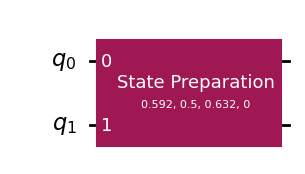

In [ ]:

# Step 3: Build PREPARE_G gate

# PREPARE_G maps:
#
#       |0...0>_idx -> |G>_idx
#
# In this Qiskit version, StatePreparation is already an
# instruction-like object, so we do NOT call .to_gate().


prepare_G_gate = StatePreparation(G_vec)
prepare_G_gate.name = "PREPARE_G"

# Optional: view PREPARE_G alone
prepare_test = QuantumCircuit(n_index_qubits)
prepare_test.append(prepare_G_gate, range(n_index_qubits))

prepare_test.draw("mpl")

In [ ]:

# Step 4: Helper functions for building SELECT

# SELECT applies:
#
#   |j>|psi> -> |j> sign(c_j) P_j |psi>
#
# These helpers let us:
#   1. control on a specific index bitstring
#   2. apply controlled Pauli operators
#   3. apply a controlled -1 sign for negative coefficients


def apply_control_on_bitstring(qc, control_qubits, bitstring):
    """
    Turn control-on-bitstring into control-on-all-ones.

    Example:
        bitstring = "010"

    For every 0 in the bitstring, apply X before the controlled operation.
    """
    for qubit, bit in zip(control_qubits, bitstring):
        if bit == "0":
            qc.x(qubit)


def undo_control_on_bitstring(qc, control_qubits, bitstring):
    """
    Undo the X gates used in apply_control_on_bitstring.
    """
    for qubit, bit in zip(control_qubits, bitstring):
        if bit == "0":
            qc.x(qubit)


def apply_multi_controlled_minus_sign(qc, control_qubits):
    """
    Apply a -1 phase when all control_qubits are |1>.

    This implements the sign(c_j) part when c_j < 0.
    """
    if len(control_qubits) == 1:
        qc.z(control_qubits[0])
    else:
        target = control_qubits[-1]
        controls = control_qubits[:-1]

        qc.h(target)
        qc.mcx(controls, target)
        qc.h(target)


def apply_multi_controlled_pauli(qc, control_qubits, target_qubit, pauli):
    """
    Apply Pauli operator to target_qubit controlled on all control_qubits = 1.
    """
    if pauli == "I":
        return

    elif pauli == "X":
        qc.mcx(control_qubits, target_qubit)

    elif pauli == "Y":
        # Correct controlled-Y:
        # Y = S X Sdg as an operator,
        # but circuit order means apply Sdg, then X, then S.
        qc.sdg(target_qubit)
        qc.mcx(control_qubits, target_qubit)
        qc.s(target_qubit)

    elif pauli == "Z":
        # Controlled-Z using H X H
        qc.h(target_qubit)
        qc.mcx(control_qubits, target_qubit)
        qc.h(target_qubit)

    else:
        raise ValueError(f"Invalid Pauli operator: {pauli}")

SELECT circuit built.
SELECT qubits = 4
SELECT depth = 14
SELECT gate count = OrderedDict([('x', 8), ('ccx', 6), ('h', 6), ('sdg', 2), ('s', 2), ('cx', 1)])


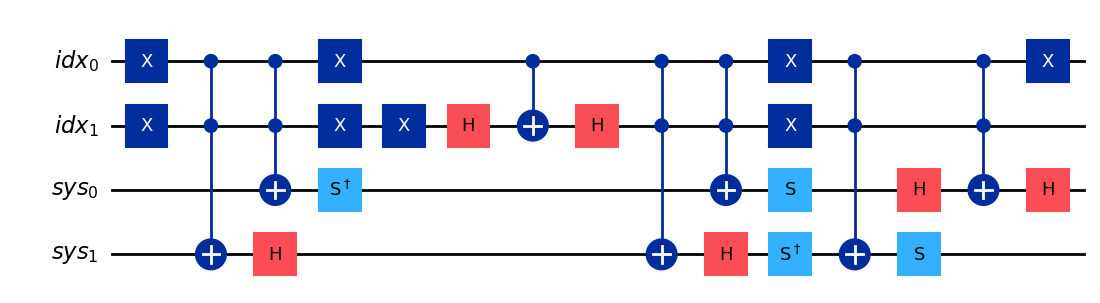

In [ ]:

# Step 5: Build SELECT circuit

# SELECT implements:
#
#   SELECT = Σ_j |j><j| ⊗ sign(c_j) P_j
#
# So:
#
#   |j>|psi> -> |j> sign(c_j) P_j |psi>
#
# Padding index states do nothing.


def build_select_circuit(terms):
    L = len(terms)
    n_system_qubits = len(terms[0][1])
    n_index_qubits = int(np.ceil(np.log2(L)))

    idx = QuantumRegister(n_index_qubits, "idx")
    sys = QuantumRegister(n_system_qubits, "sys")

    qc = QuantumCircuit(idx, sys, name="SELECT")

    for j, (coeff, pstr) in enumerate(terms):

        # Qiskit little-endian correction:
        # format(j, ...) gives normal binary order.
        # We reverse because idx[0] is the least-significant qubit.
        bitstring = format(j, f"0{n_index_qubits}b")[::-1]

        # Activate branch |idx> = |j>
        apply_control_on_bitstring(qc, idx, bitstring)

        # Negative coefficient means apply sign(c_j) = -1
        if coeff < 0:
            apply_multi_controlled_minus_sign(qc, idx)

        # Apply controlled Pauli string.
        # pstr[0] is the leftmost / most significant Pauli,
        # so it maps to reversed(sys).
        for pauli, target_qubit in zip(pstr, reversed(sys)):
            apply_multi_controlled_pauli(qc, idx, target_qubit, pauli)

        # Undo branch activation
        undo_control_on_bitstring(qc, idx, bitstring)

    return qc


select_qc = build_select_circuit(terms)

SELECT_gate = select_qc.to_gate()
SELECT_gate.name = "SELECT"

print("SELECT circuit built.")
print("SELECT qubits =", select_qc.num_qubits)
print("SELECT depth =", select_qc.depth())
print("SELECT gate count =", select_qc.count_ops())

select_qc.draw("mpl")

PREPARE_psi circuit built.
System qubits = 2
PREPARE_psi depth = 5
PREPARE_psi gate count = OrderedDict([('ry', 4), ('rz', 4), ('cx', 1)])


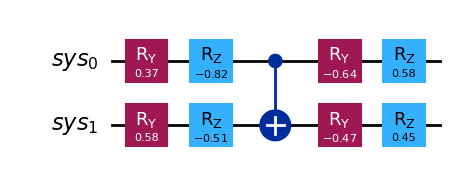

In [ ]:

# Step 6: Build a generic VQE-style trial state |psi>

# This adapts automatically to n_system_qubits.
#
# Later, U_p will encode:
#
#   p = 1/2 - 1/2 <psi|H/alpha|psi>
#
# into the probability of the ancilla being 1.


def build_trial_state_circuit():
    sys = QuantumRegister(n_system_qubits, "sys")
    qc = QuantumCircuit(sys, name="PREPARE_psi")

    # First rotation layer
    for q in range(n_system_qubits):
        qc.ry(0.37 + 0.21 * q, sys[q])
        qc.rz(-0.82 + 0.31 * q, sys[q])

    # Entangling layer: nearest-neighbor chain
    for q in range(n_system_qubits - 1):
        qc.cx(sys[q], sys[q + 1])

    # Second rotation layer
    for q in range(n_system_qubits):
        qc.ry(-0.64 + 0.17 * q, sys[q])
        qc.rz(0.58 - 0.13 * q, sys[q])

    return qc


psi_qc = build_trial_state_circuit()

PREPARE_psi_gate = psi_qc.to_gate()
PREPARE_psi_gate.name = "PREPARE_psi"

print("PREPARE_psi circuit built.")
print("System qubits =", n_system_qubits)
print("PREPARE_psi depth =", psi_qc.depth())
print("PREPARE_psi gate count =", psi_qc.count_ops())

psi_qc.draw("mpl")

U_p probability oracle built.
U_p qubits = 5
U_p depth = 3
U_p gate count = OrderedDict([('h', 2), ('PREPARE_G', 1), ('PREPARE_psi', 1), ('c-SELECT', 1)])


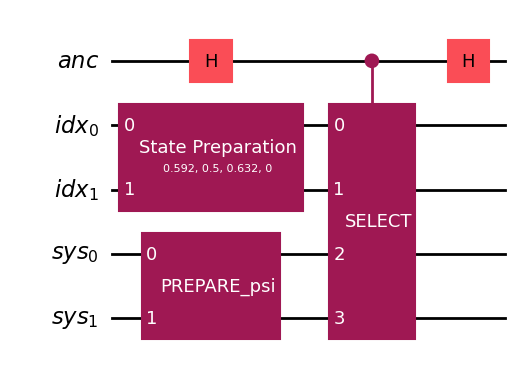

In [ ]:

# Step 7: Build probability oracle U_p

# U_p uses a Hadamard-test-style construction.
#
# It prepares:
#
#   ancilla in |+>
#   index register in |G>
#   system register in |psi>
#
# Then it applies controlled-SELECT and a final Hadamard.
#
# The result is:
#
#   P(ancilla = 1)
#   =
#   1/2 - 1/2 <psi|H/alpha|psi>


anc = QuantumRegister(1, "anc")
idx = QuantumRegister(n_index_qubits, "idx")
sys = QuantumRegister(n_system_qubits, "sys")

prob_qc = QuantumCircuit(anc, idx, sys, name="U_p")

# Prepare ancilla |+>
prob_qc.h(anc[0])

# Prepare coefficient superposition |G>
prob_qc.append(prepare_G_gate, idx)

# Prepare trial state |psi>
prob_qc.append(PREPARE_psi_gate, sys)

# Controlled SELECT, controlled by ancilla
controlled_SELECT = SELECT_gate.control(1)
controlled_SELECT.name = "c-SELECT"

prob_qc.append(controlled_SELECT, [anc[0]] + list(idx) + list(sys))

# Final Hadamard on ancilla
prob_qc.h(anc[0])

# Package U_p and U_p dagger
U_p_gate = prob_qc.to_gate()
U_p_gate.name = "U_p"

U_p_dagger_gate = U_p_gate.inverse()
U_p_dagger_gate.name = "U_p†"

print("U_p probability oracle built.")
print("U_p qubits =", prob_qc.num_qubits)
print("U_p depth =", prob_qc.depth())
print("U_p gate count =", prob_qc.count_ops())

prob_qc.draw("mpl")

In [ ]:

# Step 8: Define work-register size

# U_p acts on:
#
#   ancilla + index register + system register
#
# This combined register is the work register for G_U.


n_work_qubits = 1 + n_index_qubits + n_system_qubits

print("n_work_qubits =", n_work_qubits)

n_work_qubits = 5


In [ ]:

# Step 9: Build gate-level reflections R_good and R_zero

# R_good:
#
#   +1 phase when ancilla = 1
#   -1 phase when ancilla = 0
#
# This is:
#
#   R_good = 2Π_good - I
#
# where good means ancilla = 1.
#
#
# R_zero:
#
#   +1 phase on |000...0>
#   -1 phase on all other computational basis states
#
# This is:
#
#   R_zero = 2|0...0><0...0| - I
#
# Both are built using gates only.


def build_R_good_gate(n_work_qubits, ancilla_position=0):
    qc = QuantumCircuit(n_work_qubits, name="R_good")

    # X Z X gives:
    #
    #   |0> -> -|0>
    #   |1> -> +|1>
    #
    # on the ancilla.
    qc.x(ancilla_position)
    qc.z(ancilla_position)
    qc.x(ancilla_position)

    gate = qc.to_gate()
    gate.name = "R_good"
    return gate


def build_R_zero_gate(n_work_qubits):
    qc = QuantumCircuit(n_work_qubits, name="R_zero")

    qubits = list(range(n_work_qubits))

    # Convert control on |000...0> into control on |111...1>
    qc.x(qubits)

    # Apply -1 phase to |111...1>
    if n_work_qubits == 1:
        qc.z(qubits[0])
    else:
        target = qubits[-1]
        controls = qubits[:-1]

        qc.h(target)
        qc.mcx(controls, target)
        qc.h(target)

    # Undo the X gates
    qc.x(qubits)

    # At this point the operation is:
    #
    #   I - 2|0...0><0...0|
    #
    # Add global phase pi to get:
    #
    #   2|0...0><0...0| - I
    qc.global_phase += np.pi

    gate = qc.to_gate()
    gate.name = "R_zero"
    return gate


R_good_gate = build_R_good_gate(n_work_qubits, ancilla_position=0)
R_zero_gate = build_R_zero_gate(n_work_qubits)

print("R_good gate built.")
print("R_zero gate built.")

R_good gate built.
R_zero gate built.


G_U circuit built.
G_U qubits = 5
G_U depth = 4
G_U gate count = OrderedDict([('U_p', 1), ('R_good', 1), ('U_p†', 1), ('R_zero', 1)])


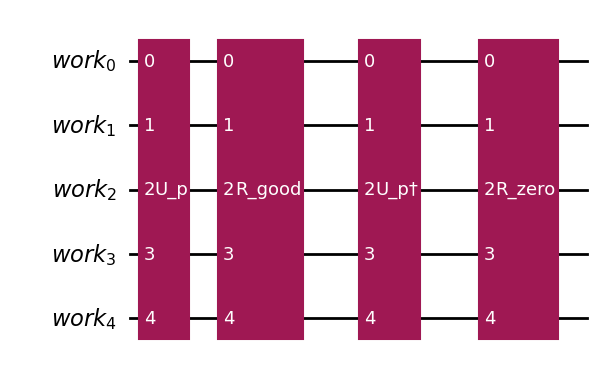

In [ ]:

# Step 10: Build G_U circuit

# Mathematical operator:
#
#   G_U = R_zero U_p† R_good U_p
#
# Circuit execution order:
#
#   1. U_p
#   2. R_good
#   3. U_p†
#   4. R_zero
#
# This is the Grover/reflection operator that converts the
# probability information p into a phase/rotation signal.


work = QuantumRegister(n_work_qubits, "work")

GU_qc = QuantumCircuit(work, name="G_U")

GU_qc.append(U_p_gate, work)
GU_qc.append(R_good_gate, work)
GU_qc.append(U_p_dagger_gate, work)
GU_qc.append(R_zero_gate, work)

G_U_gate = GU_qc.to_gate()
G_U_gate.name = "G_U"

G_U_dagger_gate = G_U_gate.inverse()
G_U_dagger_gate.name = "G_U†"

print("G_U circuit built.")
print("G_U qubits =", GU_qc.num_qubits)
print("G_U depth =", GU_qc.depth())
print("G_U gate count =", GU_qc.count_ops())

GU_qc.draw("mpl")

SELECT_G circuit built.
M = 2
power labels = [-2, -1, 0, 1, 2]
number of power states = 5
power qubits = 3
SELECT_G qubits = 8
SELECT_G depth = 17
SELECT_G gate count = OrderedDict([('x', 26), ('c3G_U†', 3), ('c3G_U', 3)])


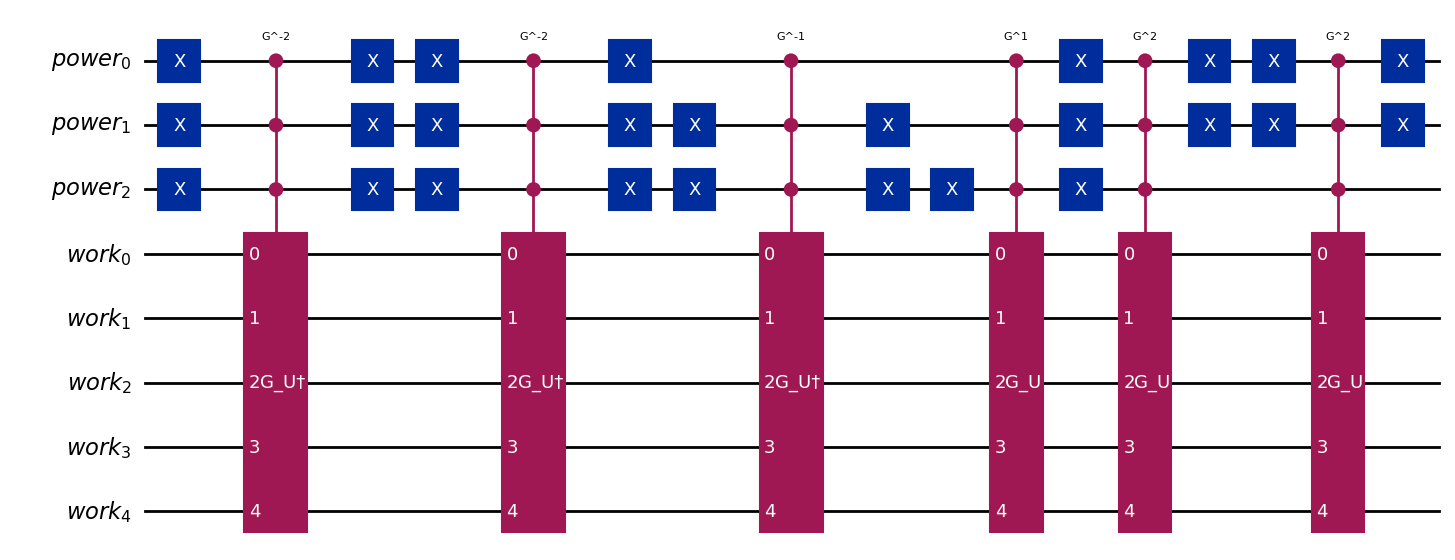

In [ ]:

# Step 11: Build SELECT_G for powers of G_U

# SELECT_G implements:
#
#   |m>|phi> -> |m> G_U^m |phi>
#
# where m ranges from -M to M.
#
# Example with M = 2:
#
#   encoded 0 -> G_U^{-2}
#   encoded 1 -> G_U^{-1}
#   encoded 2 -> I
#   encoded 3 -> G_U
#   encoded 4 -> G_U^2


import math
from qiskit import QuantumRegister, QuantumCircuit

M = 2

power_labels = list(range(-M, M + 1))
num_power_states = len(power_labels)
n_power_qubits = math.ceil(math.log2(num_power_states))

power = QuantumRegister(n_power_qubits, "power")
work = QuantumRegister(n_work_qubits, "work")

SELECT_G_qc = QuantumCircuit(power, work, name="SELECT_G")

def apply_controlled_on_int(qc, gate, control_reg, target_reg, int_value, label=None):
    """
    Apply 'gate' to target_reg controlled on control_reg == int_value.
    Qiskit uses little-endian qubit ordering, so we reverse the bitstring.
    """
    bitstring = format(int_value, f"0{len(control_reg)}b")[::-1]

    # Turn control-on-bitstring into control-on-all-ones
    for q, bit in zip(control_reg, bitstring):
        if bit == "0":
            qc.x(q)

    controlled_gate = gate.control(len(control_reg), label=label)
    qc.append(controlled_gate, list(control_reg) + list(target_reg))

    # Undo X gates
    for q, bit in zip(control_reg, bitstring):
        if bit == "0":
            qc.x(q)


for encoded_value, m in enumerate(power_labels):

    if m == 0:
        # Identity branch: do nothing
        continue

    elif m > 0:
        for _ in range(m):
            apply_controlled_on_int(
                SELECT_G_qc,
                G_U_gate,
                power,
                work,
                encoded_value,
                label=f"G^{m}"
            )

    elif m < 0:
        for _ in range(abs(m)):
            apply_controlled_on_int(
                SELECT_G_qc,
                G_U_dagger_gate,
                power,
                work,
                encoded_value,
                label=f"G^{m}"
            )

SELECT_G_gate = SELECT_G_qc.to_gate()
SELECT_G_gate.name = "SELECT_G"

print("SELECT_G circuit built.")
print("M =", M)
print("power labels =", power_labels)
print("number of power states =", num_power_states)
print("power qubits =", n_power_qubits)
print("SELECT_G qubits =", SELECT_G_qc.num_qubits)
print("SELECT_G depth =", SELECT_G_qc.depth())
print("SELECT_G gate count =", SELECT_G_qc.count_ops())

SELECT_G_qc.draw("mpl")

In [ ]:

# Step 12: Compute beta_m coefficients for phase approximation

# We approximate:
#
#   exp(i sin^2(theta)) ≈ sum_{m=-M}^{M} beta_m exp(2 i m theta)
#
# Since G_U has eigenvalues exp(±2i theta), powers of G_U
# correspond to Fourier modes exp(2 i m theta).


import numpy as np

# Use same M as SELECT_G
M = 2
power_labels = list(range(-M, M + 1))

# Number of sample points for numerical Fourier projection
num_samples = 4096

# theta grid over [0, pi]
theta_grid = np.linspace(0, np.pi, num_samples, endpoint=False)

# Target function
f_theta = np.exp(1j * (np.sin(theta_grid) ** 2))

# Compute Fourier coefficients beta_m for basis exp(2 i m theta)
# beta_m = average over theta of f(theta) * exp(-2 i m theta)
beta = {}

for m in power_labels:
    beta_m = np.mean(f_theta * np.exp(-2j * m * theta_grid))
    beta[m] = beta_m

# LCU normalization
lambda_beta = sum(abs(beta[m]) for m in power_labels)

print("beta_m coefficients:")
for m in power_labels:
    print(f"m={m:2d}: beta={beta[m]: .6f}, abs={abs(beta[m]):.6f}, phase={np.angle(beta[m]):.6f}")

print("\nlambda_beta =", lambda_beta)

# Check approximation quality on the sampled grid
f_approx = np.zeros_like(f_theta, dtype=complex)

for m in power_labels:
    f_approx += beta[m] * np.exp(2j * m * theta_grid)

max_error = np.max(np.abs(f_theta - f_approx))
mean_error = np.mean(np.abs(f_theta - f_approx))

print("Max approximation error =", max_error)
print("Mean approximation error =", mean_error)

beta_m coefficients:
m=-2: beta=-0.026858-0.014672j, abs=0.030604, phase=-2.641593
m=-1: beta= 0.116150-0.212611j, abs=0.242268, phase=-1.070796
m= 0: beta= 0.823585+0.449926j, abs=0.938470, phase=0.500000
m= 1: beta= 0.116150-0.212611j, abs=0.242268, phase=-1.070796
m= 2: beta=-0.026858-0.014672j, abs=0.030604, phase=-2.641593

lambda_beta = 1.484214769507926
Max approximation error = 0.005138049295624664
Mean approximation error = 0.003279936593713891


In [ ]:

# Step 13: Build PREPARE_beta and PHASE_beta

# We have beta_m coefficients from the previous step.
#
# PREPARE_beta:
#   |0> -> (1/sqrt(lambda_beta)) sum_m sqrt(|beta_m|) |m>
#
# PHASE_beta:
#   |m> -> exp(i arg(beta_m)) |m>
#
# Together they encode complex beta_m coefficients.


import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import StatePreparation, UnitaryGate

# Number of computational states in power register
power_dim = 2 ** n_power_qubits

# ------------------------------------------------------------
# Build amplitude vector for PREPARE_beta
# ------------------------------------------------------------

beta_amp_vec = np.zeros(power_dim, dtype=complex)

for encoded_value, m in enumerate(power_labels):
    beta_amp_vec[encoded_value] = np.sqrt(abs(beta[m]) / lambda_beta)

# Check normalization
print("PREPARE_beta norm =", np.linalg.norm(beta_amp_vec))

PREPARE_beta_gate = StatePreparation(beta_amp_vec)
PREPARE_beta_gate.name = "PREPARE_beta"

PREPARE_beta_dagger_gate = PREPARE_beta_gate.inverse()
PREPARE_beta_dagger_gate.name = "PREPARE_beta†"

# ------------------------------------------------------------
# Build PHASE_beta as a diagonal unitary on the power register
# ------------------------------------------------------------

phase_diag = np.ones(power_dim, dtype=complex)

for encoded_value, m in enumerate(power_labels):
    phase_diag[encoded_value] = np.exp(1j * np.angle(beta[m]))

PHASE_beta_matrix = np.diag(phase_diag)

PHASE_beta_gate = UnitaryGate(PHASE_beta_matrix, label="PHASE_beta")

print("PHASE_beta diagonal:")
for encoded_value, m in enumerate(power_labels):
    print(
        f"encoded={encoded_value}, m={m:2d}, "
        f"phase={phase_diag[encoded_value]: .6f}"
    )

print("PREPARE_beta and PHASE_beta built.")

PREPARE_beta norm = 1.0
PHASE_beta diagonal:
encoded=0, m=-2, phase=-0.877583-0.479426j
encoded=1, m=-1, phase= 0.479426-0.877583j
encoded=2, m= 0, phase= 0.877583+0.479426j
encoded=3, m= 1, phase= 0.479426-0.877583j
encoded=4, m= 2, phase=-0.877583-0.479426j
PREPARE_beta and PHASE_beta built.


LCU phase block built.
Total qubits = 8
Depth = 4
Gate count = OrderedDict([('PREPARE_beta', 1), ('unitary', 1), ('SELECT_G', 1), ('PREPARE_beta†', 1)])


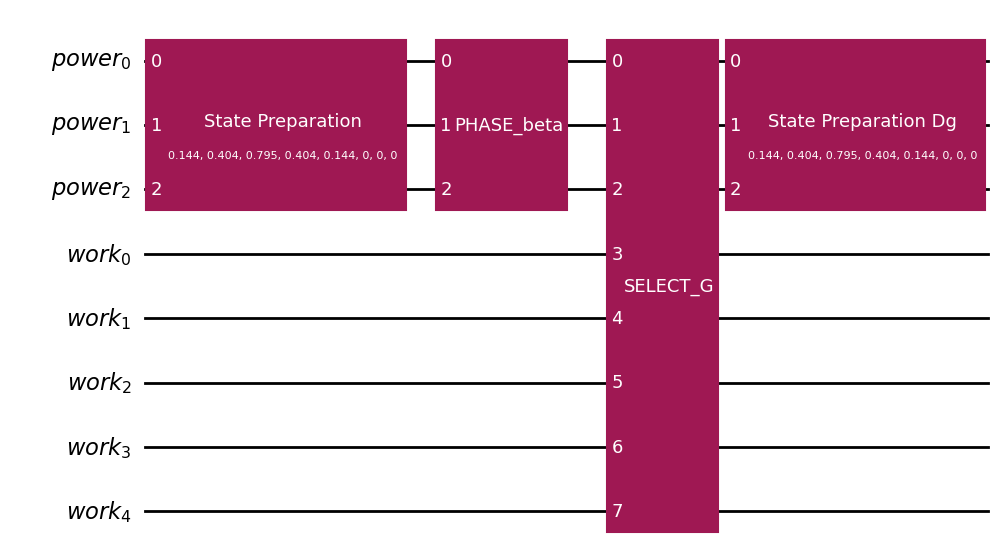

In [ ]:

# Step 14: Build LCU phase-oracle block

# U_LCU =
#   PREPARE_beta† · SELECT_G · PHASE_beta · PREPARE_beta
#
# In Qiskit append order:
#   PREPARE_beta
#   PHASE_beta
#   SELECT_G
#   PREPARE_beta†


power = QuantumRegister(n_power_qubits, "power")
work = QuantumRegister(n_work_qubits, "work")

LCU_phase_qc = QuantumCircuit(power, work, name="LCU_phase_block")

# 1. Prepare beta amplitudes
LCU_phase_qc.append(PREPARE_beta_gate, power[:])

# 2. Add complex phases of beta_m
LCU_phase_qc.append(PHASE_beta_gate, power[:])

# 3. Apply controlled powers of G_U
LCU_phase_qc.append(SELECT_G_gate, power[:] + work[:])

# 4. Unprepare beta amplitudes
LCU_phase_qc.append(PREPARE_beta_dagger_gate, power[:])

LCU_phase_gate = LCU_phase_qc.to_gate()
LCU_phase_gate.name = "LCU_phase"

print("LCU phase block built.")
print("Total qubits =", LCU_phase_qc.num_qubits)
print("Depth =", LCU_phase_qc.depth())
print("Gate count =", LCU_phase_qc.count_ops())

LCU_phase_qc.draw("mpl")

In [41]:
expanded_LCU = LCU_phase_qc.decompose(reps=5)

print("Expanded LCU depth =", expanded_LCU.depth())
print("Expanded LCU gate count =", expanded_LCU.count_ops())

#expanded_LCU.draw("mpl")

Expanded LCU depth = 572441
Expanded LCU gate count = OrderedDict([('u', 498956), ('cx', 299126), ('p', 11856)])


In [ ]:

# Step 15: Robust verification of LCU block


import numpy as np
from qiskit.quantum_info import Operator

U_LCU_mat = Operator(LCU_phase_qc).data
G_mat = Operator(GU_qc).data

dim_power = 2 ** n_power_qubits
dim_work = 2 ** n_work_qubits
dim_total = dim_power * dim_work

print("dim_power =", dim_power)
print("dim_work =", dim_work)
print("dim_total =", dim_total)
print("U_LCU shape =", U_LCU_mat.shape)
print("G_U shape =", G_mat.shape)

# ------------------------------------------------------------
# Qiskit basis ordering:
# If the circuit has registers [power, work],
# the power qubits are the lower-index qubits.
#
# So basis index is:
#     total_index = power_value + dim_power * work_value
#
# Therefore, power = 0 block is selected by:
#     row = 0 + dim_power * row_work
#     col = 0 + dim_power * col_work
# ------------------------------------------------------------

LCU_good_block = np.zeros((dim_work, dim_work), dtype=complex)

for row_work in range(dim_work):
    for col_work in range(dim_work):
        row = 0 + dim_power * row_work
        col = 0 + dim_power * col_work
        LCU_good_block[row_work, col_work] = U_LCU_mat[row, col]

# ------------------------------------------------------------
# Expected polynomial:
#   (1/lambda_beta) sum_m beta_m G_U^m
# ------------------------------------------------------------

expected_poly = np.zeros((dim_work, dim_work), dtype=complex)

for m in power_labels:
    if m == 0:
        G_power = np.eye(dim_work, dtype=complex)
    elif m > 0:
        G_power = np.linalg.matrix_power(G_mat, m)
    else:
        G_power = np.linalg.matrix_power(G_mat.conj().T, abs(m))

    expected_poly += beta[m] * G_power

expected_poly = expected_poly / lambda_beta

# ------------------------------------------------------------
# Compare
# ------------------------------------------------------------

diff = LCU_good_block - expected_poly

print("LCU block verification:")
print("Max abs difference =", np.max(np.abs(diff)))
print("Frobenius norm difference =", np.linalg.norm(diff))

KeyboardInterrupt: 

In [ ]:

# Step 15: Summary of constructed oracle pipeline


print("=" * 70)
print("ORACLE PIPELINE SUMMARY")
print("=" * 70)

print("\nHamiltonian:")
print("terms =", terms)
print("alpha =", alpha)
print("n_system_qubits =", n_system_qubits)
print("L =", L)
print("n_index_qubits =", n_index_qubits)

print("\nProbability oracle U_p:")
print("U_p qubits =", prob_qc.num_qubits)
print("U_p depth =", prob_qc.depth())
print("U_p gate count =", prob_qc.count_ops())

print("\nGrover operator G_U:")
print("G_U qubits =", GU_qc.num_qubits)
print("G_U depth =", GU_qc.depth())
print("G_U gate count =", GU_qc.count_ops())

print("\nControlled powers SELECT_G:")
print("M =", M)
print("power_labels =", power_labels)
print("n_power_qubits =", n_power_qubits)
print("SELECT_G qubits =", SELECT_G_qc.num_qubits)
print("SELECT_G depth =", SELECT_G_qc.depth())
print("SELECT_G gate count =", SELECT_G_qc.count_ops())

print("\nLCU phase block:")
print("lambda_beta =", lambda_beta)
print("LCU_phase qubits =", LCU_phase_qc.num_qubits)
print("LCU_phase depth =", LCU_phase_qc.depth())
print("LCU_phase gate count =", LCU_phase_qc.count_ops())

print("\nApproximation:")
print("Target function: exp(i sin^2(theta))")
print("Approximation: sum_m beta_m G_U^m")
print("Block contains: (1/lambda_beta) * sum_m beta_m G_U^m")
print("This approximates: (1/lambda_beta) * exp(i p)")

print("\nStatus:")
print("Built block-encoded phase oracle successfully.")
print("Full matrix verification skipped because it is expensive.")
print("=" * 70)

ORACLE PIPELINE SUMMARY

Hamiltonian:
terms = [(0.7, 'XX'), (-0.5, 'ZY'), (0.8, 'YZ')]
alpha = 2.0
n_system_qubits = 2
L = 3
n_index_qubits = 2

Probability oracle U_p:
U_p qubits = 5
U_p depth = 3
U_p gate count = OrderedDict([('h', 2), ('PREPARE_G', 1), ('PREPARE_psi', 1), ('c-SELECT', 1)])

Grover operator G_U:
G_U qubits = 5
G_U depth = 4
G_U gate count = OrderedDict([('U_p', 1), ('R_good', 1), ('U_p†', 1), ('R_zero', 1)])

Controlled powers SELECT_G:
M = 2
power_labels = [-2, -1, 0, 1, 2]
n_power_qubits = 3
SELECT_G qubits = 8
SELECT_G depth = 17
SELECT_G gate count = OrderedDict([('x', 26), ('c3G_U†', 3), ('c3G_U', 3)])

LCU phase block:
lambda_beta = 1.484214769507926
LCU_phase qubits = 8
LCU_phase depth = 4
LCU_phase gate count = OrderedDict([('PREPARE_beta', 1), ('unitary', 1), ('SELECT_G', 1), ('PREPARE_beta†', 1)])

Approximation:
Target function: exp(i sin^2(theta))
Approximation: sum_m beta_m G_U^m
Block contains: (1/lambda_beta) * sum_m beta_m G_U^m
This approximates: (1/

In [ ]:

# Optional: Save main circuits as QPY files


from qiskit import qpy

with open("probability_oracle_U_p.qpy", "wb") as f:
    qpy.dump(prob_qc, f)

with open("grover_operator_G_U.qpy", "wb") as f:
    qpy.dump(GU_qc, f)

with open("select_G_powers.qpy", "wb") as f:
    qpy.dump(SELECT_G_qc, f)

with open("lcu_phase_block.qpy", "wb") as f:
    qpy.dump(LCU_phase_qc, f)

print("Saved QPY files:")
print("- probability_oracle_U_p.qpy")
print("- grover_operator_G_U.qpy")
print("- select_G_powers.qpy")
print("- lcu_phase_block.qpy")

Saved QPY files:
- probability_oracle_U_p.qpy
- grover_operator_G_U.qpy
- select_G_powers.qpy
- lcu_phase_block.qpy
